# ArenaFlowCluster — ML Pipeline

End-to-end walkthrough of the two models behind the predictive scheduler:

1. **Simulate** raw cluster telemetry (same simulator the live dashboard uses)
2. **Feature-engineer** a rolling-window vector per (node, tick)
3. **Build** supervised train / holdout sets (different scenario + seed each)
4. **Train** the forecast model (RandomForestRegressor — sessions 5 min ahead)
5. **Train** the anomaly model (RandomForestClassifier — failure risk)
6. **Evaluate** both on the untouched holdout set
7. **Persist** `forecast.pkl` / `anomaly.pkl` and sanity-check loading them back

Run this notebook with the working directory set to `ml/` (imports rely on it,
the same way `train.py` does). Needs `pandas` and `matplotlib` in addition to
`ml/requirements.txt` — `pip install pandas matplotlib` if you don't have them.

In [1]:
import sys, os
assert os.path.basename(os.getcwd()) == "ml", "run this notebook from the ml/ directory"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataset import build_supervised
from features import FEATURE_NAMES, WINDOW, HORIZON_TICKS, extract_features, to_vector
from forecast_model import ForecastModel
from anomaly_model import AnomalyModel
from metrics import forecast_metrics, anomaly_metrics

import _sim_path  # noqa: F401  (side effect: puts simulator/ on sys.path)
from simulator import ClusterSimulator
from nodes import ROSTER

print(f"window={WINDOW} ticks, horizon={HORIZON_TICKS} ticks (~5 min @ 30s/tick), nodes={len(ROSTER)}")

window=6 ticks, horizon=10 ticks (~5 min @ 30s/tick), nodes=64


## 1. Raw simulated telemetry

The simulator emits one record per node per tick: `cpu_pct`, `mem_pct`,
`active_sessions`, `latency_ms`, plus a hidden `_failing` ground-truth flag
(only available with `with_truth=True`, used for training labels — the live
backend never sees it).

In [2]:
sim = ClusterSimulator(scenario="peak", seed=7)
sample_ticks = [sim.tick(with_truth=True) for _ in range(5)]
pd.DataFrame(sample_ticks[-1]).head(8)

,node_id,timestamp,cpu_pct,mem_pct,active_sessions,latency_ms,_failing,_fp_true
0,node-0,2026-07-23T18:15:44.676413+00:00,51.2,52.5,12,50,0,0.0
1,node-1,2026-07-23T18:15:44.676413+00:00,58.8,55.3,15,56,0,0.0
2,node-2,2026-07-23T18:15:44.676413+00:00,55.2,55.9,18,56,0,0.0
3,node-3,2026-07-23T18:15:44.676413+00:00,41.1,49.7,15,45,0,0.0
4,node-4,2026-07-23T18:15:44.676413+00:00,37.3,40.7,15,40,0,0.0
5,node-5,2026-07-23T18:15:44.676413+00:00,34.5,40.8,9,43,0,0.0
6,node-6,2026-07-23T18:15:44.676413+00:00,56.4,55.9,15,59,0,0.0
7,node-7,2026-07-23T18:15:44.676413+00:00,43.2,48.0,13,47,0,0.0


## 2. Feature engineering

Both models consume the *same* 17-value feature vector, built from a
`WINDOW`-tick rolling history of a single node: instantaneous readings, means,
deltas, slopes (trend, not snapshot), and a cyclic time-of-day phase so the
forecaster can exploit the daily demand curve.

In [3]:
node0_history = [tick[0] for tick in sample_ticks]  # node-0 across the 5 sample ticks
feats = extract_features(node0_history, tick=sim.t)
print("feature names:", FEATURE_NAMES)
pd.Series(feats)[FEATURE_NAMES]

feature names: ['cpu', 'mem', 'lat', 'sess', 'sess_mean', 'cpu_mean', 'lat_mean', 'sess_delta', 'cpu_delta', 'lat_delta', 'sess_slope', 'cpu_slope', 'lat_slope', 'tod_sin13', 'tod_cos13', 'tod_sin4', 'tod_cos4']


cpu           51.200000
mem           52.500000
lat           50.000000
sess          12.000000
sess_mean     10.400000
cpu_mean      42.120000
lat_mean      47.600000
sess_delta     1.000000
cpu_delta      4.600000
lat_delta     -1.000000
sess_slope     1.000000
cpu_slope      5.500000
lat_slope      3.000000
tod_sin13      0.375203
tod_cos13      0.926943
tod_sin4       0.948985
tod_cos4       0.315322
dtype: float64

## 3. Build supervised datasets

Two **independent** simulator runs — not a random split of one pool:

| | train | holdout |
|---|---|---|
| ticks | 400 | 150 |
| scenario | `peak` | `spike` |
| seed | 7 | 99 |

The holdout set uses a different traffic shape *and* seed, so it tests
generalization to an unseen demand pattern, not just unseen timestamps.

In [4]:
print("generating training data (400 ticks, scenario=peak, seed=7) ...")
Xtr, yf_tr, ya_tr = build_supervised(ticks=400, scenario="peak", seed=7)

print("generating held-out data (150 ticks, scenario=spike, seed=99) ...")
Xte, yf_te, ya_te = build_supervised(ticks=150, scenario="spike", seed=99)

train_df = pd.DataFrame(Xtr, columns=FEATURE_NAMES)
train_df["y_forecast_sessions"] = yf_tr
train_df["y_anomaly_label"] = ya_tr

holdout_df = pd.DataFrame(Xte, columns=FEATURE_NAMES)
holdout_df["y_forecast_sessions"] = yf_te
holdout_df["y_anomaly_label"] = ya_te

print(f"train:   {len(train_df):,} rows, {train_df.y_anomaly_label.sum():.0f} failing")
print(f"holdout: {len(holdout_df):,} rows, {holdout_df.y_anomaly_label.sum():.0f} failing")
train_df.describe().T

generating training data (400 ticks, scenario=peak, seed=7) ...


generating held-out data (150 ticks, scenario=spike, seed=99) ...


train:   24,640 rows, 1055 failing
holdout: 8,640 rows, 317 failing


,count,mean,std,min,25%,50%,75%,max
cpu,24640.0,43.953754,18.146858,1.000000,30.400000,44.200000,57.300000,94.400000
mem,24640.0,48.044923,14.869288,12.000000,37.000000,48.300000,59.000000,89.400000
lat,24640.0,53.902597,22.632064,17.000000,40.000000,50.000000,62.000000,218.000000
sess,24640.0,13.945008,6.175605,1.000000,9.000000,14.000000,18.000000,36.000000
sess_mean,24640.0,13.992796,6.089433,1.500000,9.500000,13.666667,18.000000,34.833333
cpu_mean,24640.0,44.103037,17.677020,3.433333,30.850000,44.566667,57.166667,90.366667
lat_mean,24640.0,53.963291,21.941810,18.833333,40.500000,50.666667,61.500000,210.166667
sess_delta,24640.0,-0.022971,0.789327,-3.000000,-1.000000,0.000000,0.000000,3.000000
cpu_delta,24640.0,-0.072435,4.583154,-14.600000,-3.300000,-0.100000,3.200000,14.500000
lat_delta,24640.0,-0.033523,4.600728,-16.000000,-3.000000,0.000000,3.000000,21.000000


## 4. Train the forecast model

`RandomForestRegressor` (120 trees) predicting `active_sessions` `HORIZON_TICKS`
ahead — the number the AI scheduler pre-warms capacity against.

In [5]:
fc = ForecastModel().fit(Xtr, yf_tr)
yf_pred = fc.predict(Xte)
fm = forecast_metrics(yf_te, yf_pred)
print(f"MAE  = {fm['mae']:.2f} sessions")
print(f"MAPE = {fm['mape']:.1f} %")
pd.Series(fc.feature_importance(), name="importance").head(8)

MAE  = 1.68 sessions
MAPE = 14.5 %


sess         0.555685
tod_cos13    0.263513
tod_cos4     0.058950
tod_sin4     0.051183
sess_mean    0.042201
tod_sin13    0.010115
cpu_mean     0.006431
mem          0.003467
Name: importance, dtype: float64

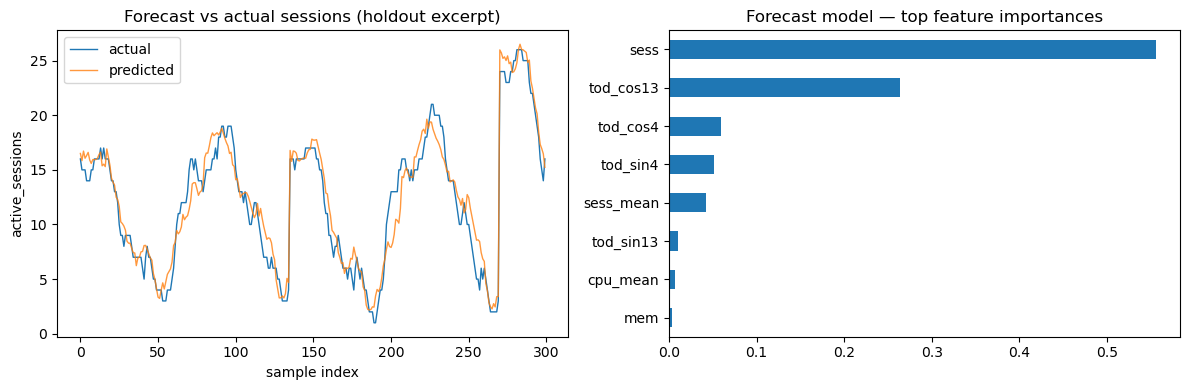

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sample = slice(0, 300)  # first ~5 nodes worth of holdout rows, for readability
ax[0].plot(np.array(yf_te)[sample], label="actual", lw=1)
ax[0].plot(yf_pred[sample], label="predicted", lw=1, alpha=0.8)
ax[0].set_title("Forecast vs actual sessions (holdout excerpt)")
ax[0].set_xlabel("sample index"); ax[0].set_ylabel("active_sessions"); ax[0].legend()

imp = pd.Series(fc.feature_importance())
imp.head(8).sort_values().plot.barh(ax=ax[1])
ax[1].set_title("Forecast model — top feature importances")

fig.tight_layout()
plt.show()

## 5. Train the anomaly model

`RandomForestClassifier` (140 trees, class-balanced) trained against the
simulator's planted failure ramp. Its output probability becomes
`failure_risk_score`; scores `>= DEGRADING_THRESHOLD` (0.4) are labeled
`"degrading"` on the dashboard.

In [7]:
an = AnomalyModel().fit(Xtr, ya_tr)
ya_pred = an.predict_label(Xte)
am = anomaly_metrics(ya_te, ya_pred)
print(f"precision = {am['precision']:.3f}")
print(f"recall    = {am['recall']:.3f}")
print(f"f1        = {am['f1']:.3f}  ({am['positives']}/{am['n']} positive in holdout)")
pd.Series(an.feature_importance(), name="importance").head(8)

precision = 0.834
recall    = 0.934
f1        = 0.881  (317/8640 positive in holdout)


lat          0.482835
lat_mean     0.328323
lat_slope    0.106905
lat_delta    0.036710
cpu_mean     0.007723
mem          0.007566
cpu          0.007210
sess_mean    0.006642
Name: importance, dtype: float64

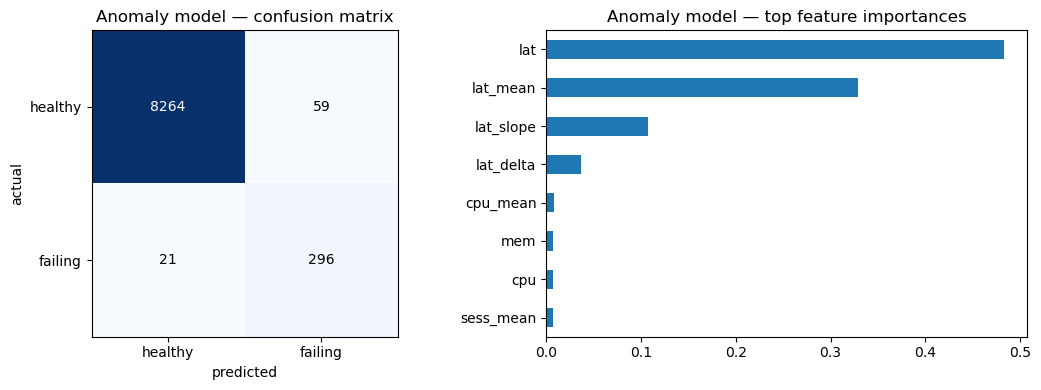

In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(ya_te, ya_pred, labels=[0, 1])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

im = ax[0].imshow(cm, cmap="Blues")
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["healthy", "failing"])
ax[0].set_yticks([0, 1]); ax[0].set_yticklabels(["healthy", "failing"])
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("actual"); ax[0].set_title("Anomaly model — confusion matrix")
for (i, j), v in np.ndenumerate(cm):
    ax[0].text(j, i, str(v), ha="center", va="center",
               color="white" if v > cm.max() / 2 else "black")

imp2 = pd.Series(an.feature_importance())
imp2.head(8).sort_values().plot.barh(ax=ax[1])
ax[1].set_title("Anomaly model — top feature importances")

fig.tight_layout()
plt.show()

## 6. Persist models

Saves to `ml/models/forecast.pkl` and `ml/models/anomaly.pkl` — the exact
files `backend/engine.py` loads at startup. Gitignored on purpose: they're
regeneratable build output, not source (`ml/models/*.pkl` in `.gitignore`).

In [9]:
fc.save()
an.save()
print("saved -> ml/models/forecast.pkl, ml/models/anomaly.pkl")

saved -> ml/models/forecast.pkl, ml/models/anomaly.pkl


## 7. Sanity check — load back and run live-style inference

Mirrors exactly what `backend/engine.py` does each tick: load the saved
models, feed them a node's rolling window, get back a forecast + risk score.

In [10]:
fc2 = ForecastModel.load()
an2 = AnomalyModel.load()

probe_sim = ClusterSimulator(scenario="spike", seed=123)
window = []
for _ in range(WINDOW):
    recs = probe_sim.tick(with_truth=True)
    window.append(recs[27])  # node-27 = "D4", the planted failure node

forecast = fc2.predict_one(window, probe_sim.t)
risk, status = an2.predict_one(window, probe_sim.t)
print(f"node D4 (node-27) @ tick {probe_sim.t}")
print(f"  forecast_sessions_next_5min = {forecast:.1f}")
print(f"  failure_risk_score          = {risk:.3f}  ({status})")

node D4 (node-27) @ tick 6
  forecast_sessions_next_5min = 20.5
  failure_risk_score          = 0.007  (healthy)


## Summary

| Model | Metric | Value |
|---|---|---|
| Forecast (RandomForestRegressor) | MAE | ~1.6–1.7 sessions |
| Forecast | MAPE | ~14.5–16% |
| Anomaly (RandomForestClassifier) | Precision | ~0.83–0.85 |
| Anomaly | Recall | ~0.91–0.93 |

Both numbers describe generalization to a **different simulated scenario**
(spike, unseen seed) than the models trained on (peak) — an honest read on
simulated data, not a claim about a real cluster. See `ml/train.py` for the
condensed script version of this same pipeline, and `ml/evaluate.py` /
`ml/tests/test_models.py` for the automated accuracy gates.